# Graphics utilities in RobotBlockSet

The `robotblockset.graphics` module provides Matplotlib-based helpers for visualizing robot paths, Cartesian trajectories, joint trajectories, forces and torques, coordinate frames, simple geometry, and image grids.

This notebook gives a practical overview of the most useful functions in the module. It shows common input shapes, typical plotting patterns, and small self-contained examples that can be reused in scripts or other tutorials.


## Function reference

The table below lists the public functions in `robotblockset.graphics`, together with simplified call signatures and short descriptions.

| Function | Description |
| --- | --- |
| `plotucs(x, UCS_length=np.ones(3), UCS_linewidth=1, UCS_labels=None, UCS_handles=None, ax=None)` | Plot a coordinate frame, or UCS (User Coordinate System). |
| `plotspheregrid(radius=1.0, alpha=1.0, pos=np.array([0, 0, 0]), N=36, ax=None)` | Plot a sphere grid in 3D space. |
| `plotarrow(p1, p2, radius=0.02, head_length=0.12, head_radius=0.04, color="k", ax=None)` | Plot an arrow from point `p1` to point `p2`. |
| `plotcpos_ori(t, x=None, T=None, p=None, R=None, Q=None, typ="Pos", graph="Time", grid=True, UCS=False, label=False, alpha=0.1, ori_sel=[1, 2], fig_num="Cartesian poses", ax=None)` | Plot Cartesian positions or orientations as time/parameter signals or as 3D geometry. |
| `plotcpath(s, path, points=None, auxpoints=None, grid=True, UCS=True, label=True, ori_sel=[0, 1], normscale=1, fig_num="Cartesian path", **kwargs)` | Plot a Cartesian path, including positions, orientations, and path derivatives. |
| `plotctraj(t, xt, *args, grid=True, fig_num="Cartesian trajectory", ax=None, **kwargs)` | Plot a Cartesian trajectory over time, including derivatives when available. |
| `plotpathpoints(x=None, T=None, p=None, label=False, fig_num="Path", ax=None, **kwargs)` | Plot discrete Cartesian path points or poses. |
| `plotwrench(t, FTt, grid=True, ax=None, fig_num="Task forces", **kwargs)` | Plot force and torque signals over time. |
| `plotjtraj(t, qt, *args, grid=True, ax=None, fig_num="Joint trajectory", **kwargs)` | Plot joint positions, velocities, and accelerations. |
| `plotjctraj(t, qt, xt, *args, grid=True, ax=None, fig_num="Joint and task trajectory", **kwargs)` | Plot joint-space and task-space trajectory signals together. |
| `plot_circle(r=1, center=(0, 0), color="b", linestyle="-", linewidth=2)` | Plot a 2D circle with a given radius and center. |
| `linkxaxes(ax=None)` | Share the x-axis between axes in a list or array of axes. |
| `display_images(images, bgr2rgb=False)` | Display a collection of images in a near-square grid. |


## What is covered

The tutorial is organized into six groups:

- frame and geometry helpers: `plotucs`, `plotspheregrid`, `plotarrow`, `plot_circle`
- Cartesian path and pose visualization: `plotpathpoints`, `plotcpos_ori`, `plotcpath`, `plotctraj`
- joint-space and wrench plotting: `plotjtraj`, `plotjctraj`, `plotwrench`, `linkxaxes`
- image display helper: `display_images`

Most Cartesian plotting functions in this module work with poses in the RobotBlockSet compact pose format `(x, y, z, qw, qx, qy, qz)`. The examples below therefore generate poses with `prpy2x`.


In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

from robotblockset.graphics import *
from robotblockset.transformations import prpy2x, map_pose
from robotblockset.tools import gradientCartesianPath, gradientPath

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


In [2]:
# Shared synthetic data used throughout the tutorial.

t = np.linspace(0.0, 6.0, 250)
s = np.linspace(0.0, 1.0, 160)

# Cartesian waypoints: [x, y, z, roll, pitch, yaw]
waypoints_prpy = np.array([
    [-0.25, -0.20, 0.05,  0.0,  0.0,  0.0],
    [-0.10,  0.15, 0.18,  0.1, -0.2,  0.5],
    [ 0.20,  0.22, 0.12, -0.2,  0.3,  1.0],
    [ 0.35, -0.05, 0.30,  0.2,  0.1,  1.4],
])
waypoints = prpy2x(waypoints_prpy)

# Smooth pose sequence for path and trajectory plots.
path_prpy = np.column_stack([
    -0.30 + 0.60 * s,
     0.18 * np.sin(2 * np.pi * s),
     0.12 + 0.15 * s + 0.04 * np.sin(np.pi * s),
     0.25 * np.sin(2 * np.pi * s),
     0.18 * np.cos(np.pi * s),
     1.35 * s,
])
xt = prpy2x(path_prpy)

# Joint-space data.
qt = np.column_stack([
    0.7 * np.sin(t),
    0.4 * np.cos(0.7 * t),
    0.3 * np.sin(1.4 * t + 0.3),
])
qdt = gradientPath(qt, t)
qddt = gradientPath(qdt, t)

# Cartesian derivatives and a synthetic wrench.
xdt = gradientCartesianPath(xt, s)
xddt = gradientPath(xdt, s)
FTt = np.column_stack([
    12 * np.sin(1.2 * t),
    7 * np.cos(0.8 * t),
    3 * np.sin(0.5 * t + 0.2),
    0.6 * np.sin(1.1 * t),
    0.4 * np.cos(1.5 * t),
    0.3 * np.sin(0.7 * t),
])


## 1. Coordinate frames and geometric helpers

`plotucs` draws a coordinate frame from a pose, quaternion, rotation matrix, or translation vector. `plotspheregrid` is useful when visualizing orientations in 3D, while `plotarrow` adds lightweight directional annotations between two points.

These helpers are typically combined when explaining reference frames, tool directions, local coordinate systems, or geometry around a path.


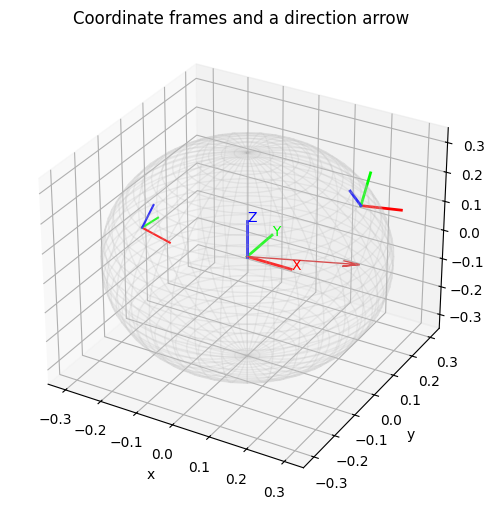

In [3]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")

base = prpy2x([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
tool = prpy2x([0.25, 0.10, 0.20, 0.15, -0.10, 0.60])
aux_T = map_pose(p=[-0.20, -0.15, 0.12], RPY=[0.0, 0.3, -0.2], out="T")

plotspheregrid(radius=0.35, alpha=0.10, ax=ax)
plotucs(base, UCS_length=0.12, UCS_linewidth=2, UCS_labels=["X", "Y", "Z"], ax=ax)
plotucs(tool, UCS_length=0.10, UCS_linewidth=2, ax=ax)
plotucs(aux_T, UCS_length=0.08, UCS_linewidth=1.5, ax=ax)
plotarrow(base[:3], tool[:3], color="tab:red", ax=ax)

ax.set_title("Coordinate frames and a direction arrow")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_box_aspect((1, 1, 0.8))


`plot_circle` is the only explicitly 2D helper in this module. It is useful for simple annotations, planar footprints, and debug geometry on standard Matplotlib axes.


Text(0, 0.5, 'y')

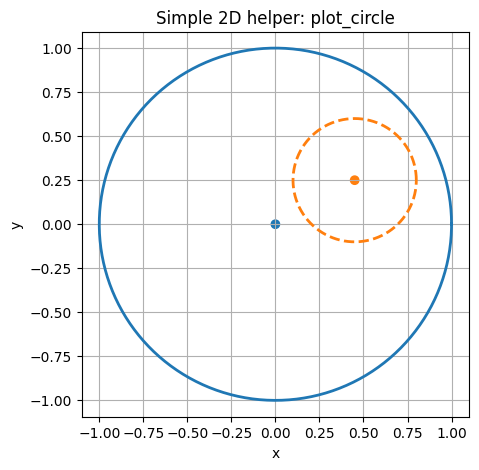

In [4]:
plt.figure(figsize=(5, 5))
plot_circle(r=1.0, center=(0.0, 0.0), color="tab:blue", linewidth=2)
plot_circle(r=0.35, center=(0.45, 0.25), color="tab:orange", linestyle="--")
plt.scatter([0.0, 0.45], [0.0, 0.25], c=["tab:blue", "tab:orange"])
plt.axis("equal")
plt.title("Simple 2D helper: plot_circle")
plt.xlabel("x")
plt.ylabel("y")

## 2. Path points and pose views

`plotpathpoints` is the simplest entry point for a Cartesian path: it shows the discrete points or poses in 3D. `plotcpos_ori` gives more focused views of the same data, either as position/orientation signals over a parameter or as 3D geometry.

A useful workflow is to start with `plotpathpoints` to inspect the overall path, then switch to `plotcpos_ori` when you need to inspect translation or orientation in more detail.


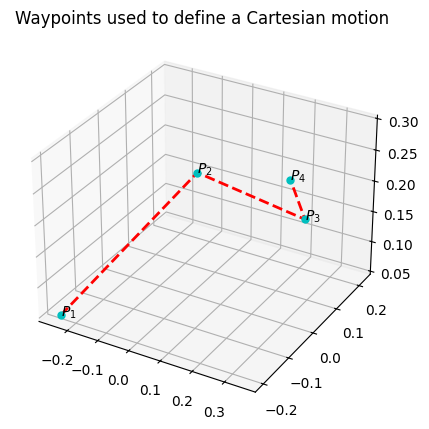

In [5]:
plotpathpoints(x=waypoints, label=True, fig_num="Waypoints")
_ = plt.title("Waypoints used to define a Cartesian motion")

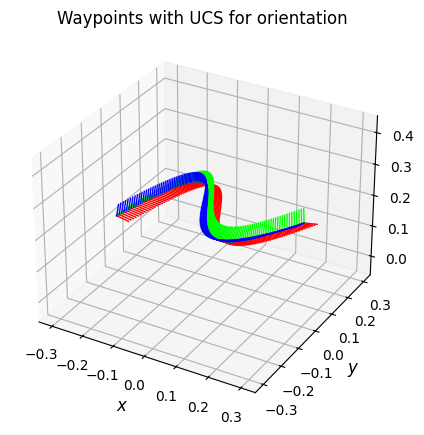

In [6]:
plotcpos_ori(s, x=xt, typ="Pos", graph="3D", UCS=True, fig_num="Cartesian positions")
_ = plt.title("Waypoints with UCS for orientation")

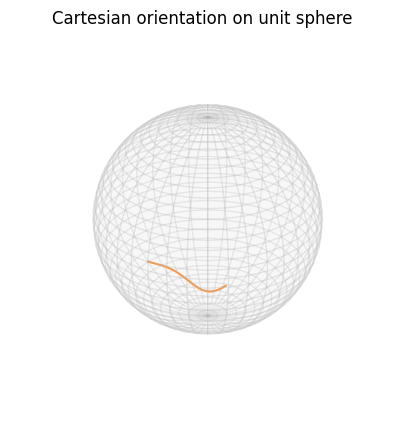

In [7]:

_, ax = plotcpos_ori(s, x=xt, typ="Ori", graph="3D", alpha=0.15, fig_num="Cartesian orientations")
ax.view_init(elev=30, azim=30)
_ = plt.title("Cartesian orientation on unit sphere")


Time-domain views are useful when you want to verify continuity, inspect individual signal components, or compare position and orientation trends directly.


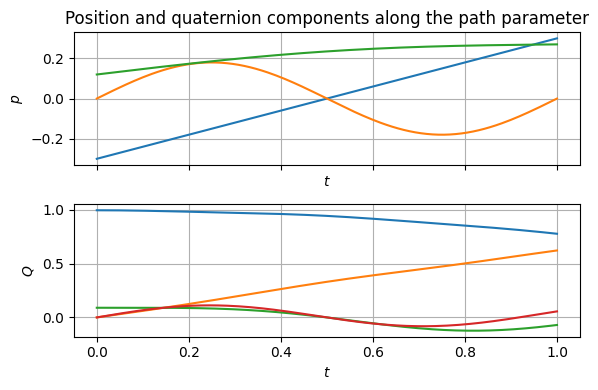

In [17]:
fig, ax = plt.subplots(2, 1, figsize=(6, 4), sharex=True)

plotcpos_ori(s, x=xt, typ="Pos", graph="Time", ax=ax[0])
plotcpos_ori(s, x=xt, typ="Ori", graph="Time", ax=ax[1])
linkxaxes(ax)

ax[0].set_title("Position and quaternion components along the path parameter")
plt.tight_layout()


## 3. Combined Cartesian path diagnostics

`plotcpath` is the most complete path-visualization utility in the module. It combines:

- a 3D position plot,
- an orientation plot on a sphere,
- path-parameter evolution and derivative plots,
- optional waypoints and auxiliary points.

Use it when you want one figure that summarizes the full geometric path rather than only one aspect of it.


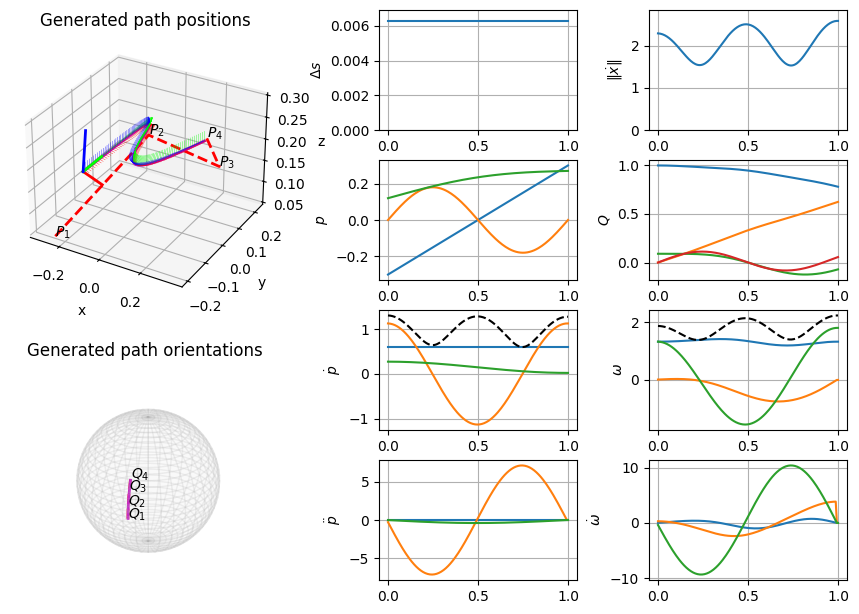

In [9]:
_, ax = plotcpath(s, xt, points=waypoints, UCS=True, label=True, fig_num="Complete Cartesian path")
ax[1].view_init(elev=30, azim=60)

## 4. Cartesian trajectories versus time

`plotctraj` is the time-based complement to `plotcpath`. It plots position, velocity, acceleration, quaternion, angular velocity, and angular acceleration in aligned subplots.

If velocity and acceleration are not passed explicitly, the function estimates them numerically. Passing precomputed derivatives is useful when the trajectory was generated analytically or by another module.


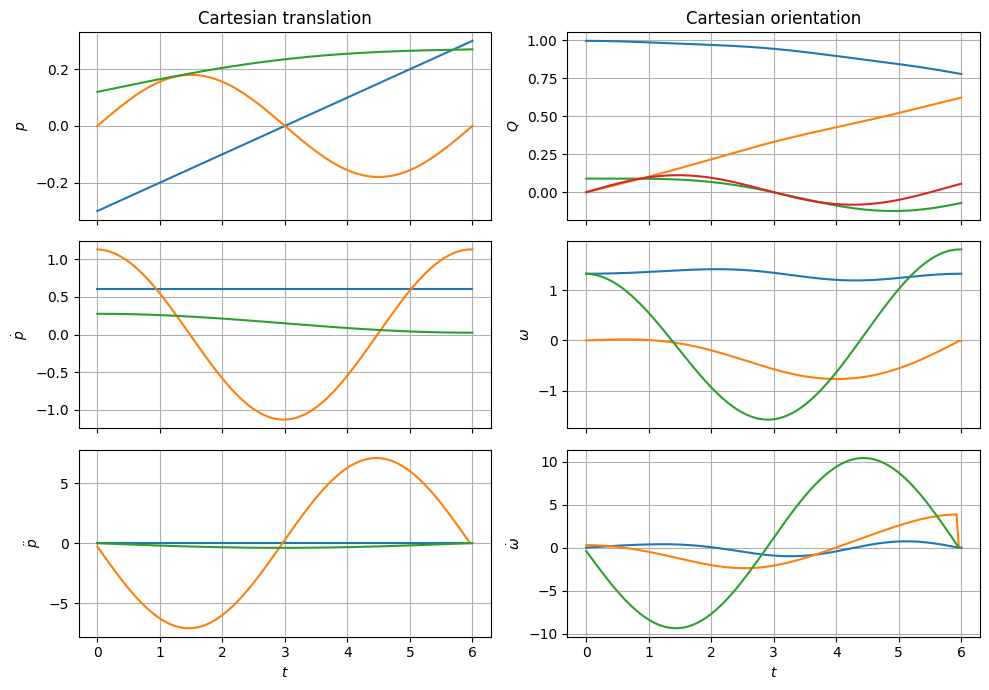

In [10]:
t_traj = np.linspace(0.0, 6.0, len(xt))
fig, ax = plt.subplots(3, 2, figsize=(10, 7), sharex="col")

plotctraj(t_traj, xt, xdt, xddt, ax=ax)
linkxaxes(ax[:, 0])
linkxaxes(ax[:, 1])

ax[0, 0].set_title("Cartesian translation")
ax[0, 1].set_title("Cartesian orientation")
plt.tight_layout()


## 5. Joint trajectories, joint/task comparison, and wrench plots

The module also contains helpers for common manipulator diagnostics:

- `plotjtraj` for joint positions, velocities, and accelerations,
- `plotjctraj` for a combined view of joint-space and Cartesian-space signals,
- `plotwrench` for force and torque histories.

These functions are useful when you want consistent plotting conventions across robot-independent scripts.


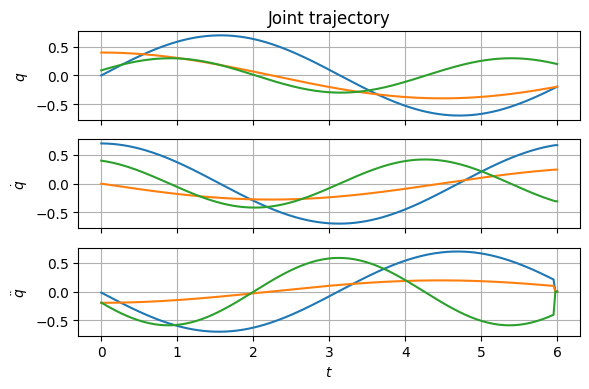

In [16]:
fig, ax = plt.subplots(3, 1, figsize=(6, 4), sharex=True)
plotjtraj(t, qt, qdt, qddt, ax=ax)
linkxaxes(ax)
ax[0].set_title("Joint trajectory")
plt.tight_layout()


Reuse the Cartesian path as a task-space signal with the same sample count as the joint trajectory.


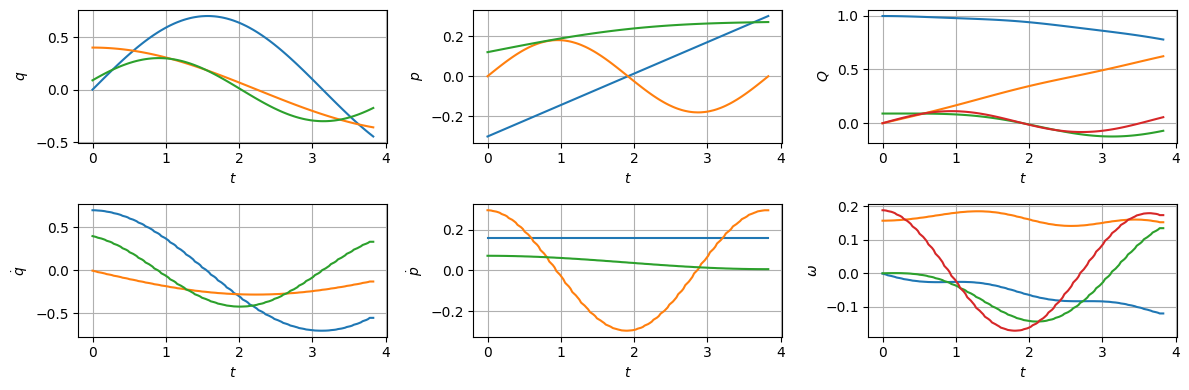

In [19]:
idx = np.linspace(0, len(xt) - 1, len(t) // 2).astype(int)
xt_joint_demo = xt[idx]
plotjctraj(t[idx], qt[idx], xt_joint_demo)
plt.tight_layout()


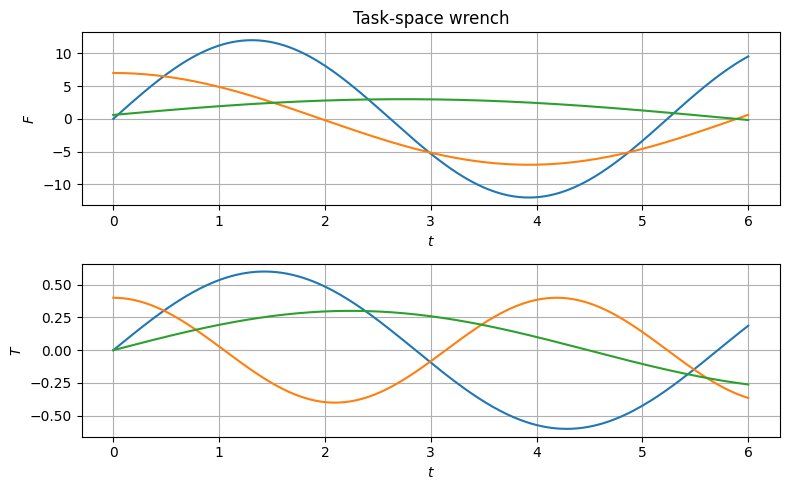

In [13]:
_, ax = plotwrench(t, FTt)
linkxaxes(ax)
ax[0].set_title("Task-space wrench")
plt.tight_layout()

## 6. Displaying image collections

`display_images` arranges a sequence of images into a near-square grid. It is convenient for quick checks of camera frames, masks, synthetic image batches, or intermediate vision results.

Create a few synthetic images so the example stays self-contained.

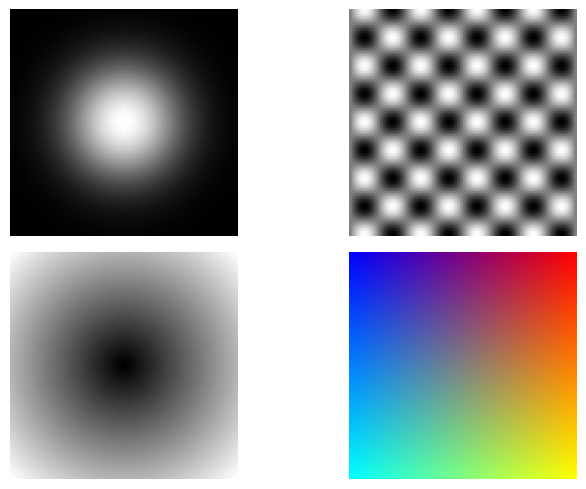

In [15]:
xx, yy = np.meshgrid(np.linspace(-1, 1, 80), np.linspace(-1, 1, 80))
images = [
    np.exp(-(xx**2 + yy**2) * 4),
    np.sin(4 * np.pi * xx) * np.cos(4 * np.pi * yy),
    np.sqrt(xx**2 + yy**2),
    np.dstack([
        0.5 + 0.5 * xx,
        0.5 + 0.5 * yy,
        0.5 - 0.5 * xx,
    ]),
]

display_images(images)
